# Cálculo de Métricas Estructurales — Cascarones de Sokoban
Procesa los cascarones ya extraídos y calcula métricas estructurales para selección sistemática.

In [1]:
# ── Dependencias ──────────────────────────────────────────────────────────────
# pip install pandas numpy scipy matplotlib seaborn scikit-learn
import re
import numpy as np
import pandas as pd
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from pathlib import Path

## 1. Parseo de cascarones

In [2]:
def parse_shells_file(filepath):
    shells = []
    current = {}
    grid_lines = []
    in_grid = False

    with open(filepath, encoding='utf-8') as f:
        for raw in f:
            line = raw.rstrip('\n').rstrip('\r')

            if line.startswith('Shell ID:'):
                current = {'id': int(line.split(':')[1].strip())}
                grid_lines = []
                in_grid = False

            elif line.startswith('Width:'):
                current['width'] = int(line.split(':')[1].strip())

            elif line.startswith('Height:'):
                current['height'] = int(line.split(':')[1].strip())
                in_grid = True

            elif line.startswith('=' * 10):
                if current and grid_lines:
                    current['grid'] = grid_lines
                    shells.append(current)
                in_grid = False
                grid_lines = []
                current = {}

            elif in_grid:
                # ignorar líneas vacías ANTES de que empiece el tablero
                if not grid_lines and line.strip() == '':
                    continue
                grid_lines.append(line)

    if current and grid_lines:
        current['grid'] = grid_lines
        shells.append(current)

    return shells


# ── Ajusta la ruta a tu archivo de cascarones ──────────────────────────────
SHELLS_FILE = '../2_shelders/all_shells_max15.txt'   # <-- cambia aquí
shells = parse_shells_file(SHELLS_FILE)
print(f'Cascarones cargados: {len(shells)}')
print('Ejemplo shell ID', shells[0]['id'], '— grid[0]:', shells[0]['grid'][0])

Cascarones cargados: 851
Ejemplo shell ID 1 — grid[0]:           ###


## 2. Funciones de métricas estructurales

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Utilidades de grilla
# ─────────────────────────────────────────────────────────────────────────────

def normalize_grid(grid):
    """Normaliza filas al mismo ancho rellenando con espacio."""
    w = max(len(r) for r in grid)
    return [r.ljust(w) for r in grid]


def bfs_reachable(grid, start_r, start_c, passable=(' ',)):
    """BFS desde (start_r, start_c). Retorna set de celdas alcanzables."""
    rows, cols = len(grid), len(grid[0])
    visited = set()
    q = deque([(start_r, start_c)])
    visited.add((start_r, start_c))
    while q:
        r, c = q.popleft()
        for dr, dc in ((-1,0),(1,0),(0,-1),(0,1)):
            nr, nc = r+dr, c+dc
            if 0 <= nr < rows and 0 <= nc < cols \
               and (nr, nc) not in visited \
               and grid[nr][nc] in passable:
                visited.add((nr, nc))
                q.append((nr, nc))
    return visited


def find_bounding_box(grid):
    """Retorna (min_r, max_r, min_c, max_c) del área encerrada por muros."""
    wall_positions = [(r, c)
                      for r, row in enumerate(grid)
                      for c, ch in enumerate(row) if ch == '#']
    if not wall_positions:
        return 0, len(grid)-1, 0, len(grid[0])-1
    rs = [p[0] for p in wall_positions]
    cs = [p[1] for p in wall_positions]
    return min(rs), max(rs), min(cs), max(cs)


def get_interior_cells(grid):
    """
    Retorna las celdas de la región navegable más grande.
    Excluye espacios exteriores Y regiones encerradas inaccesibles.
    """
    rows, cols = len(grid), len(grid[0])

    # flood desde bordes para identificar exterior
    exterior = set()
    q = deque()
    for r in range(rows):
        for c in [0, cols-1]:
            if grid[r][c] == ' ' and (r,c) not in exterior:
                exterior.add((r,c)); q.append((r,c))
    for c in range(cols):
        for r in [0, rows-1]:
            if grid[r][c] == ' ' and (r,c) not in exterior:
                exterior.add((r,c)); q.append((r,c))
    while q:
        r,c = q.popleft()
        for dr,dc in ((-1,0),(1,0),(0,-1),(0,1)):
            nr,nc = r+dr,c+dc
            if 0<=nr<rows and 0<=nc<cols and (nr,nc) not in exterior and grid[nr][nc]==' ':
                exterior.add((nr,nc)); q.append((nr,nc))

    # todos los espacios no-exteriores
    candidates = {(r,c) for r in range(rows) for c in range(cols)
                  if grid[r][c]==' ' and (r,c) not in exterior}

    # encontrar todas las regiones separadas y quedarse con la más grande
    visited = set()
    largest = set()
    for start in candidates:
        if start not in visited:
            region = set()
            q2 = deque([start])
            visited.add(start)
            while q2:
                r,c = q2.popleft()
                region.add((r,c))
                for dr,dc in ((-1,0),(1,0),(0,-1),(0,1)):
                    nr,nc = r+dr,c+dc
                    if (nr,nc) in candidates and (nr,nc) not in visited:
                        visited.add((nr,nc)); q2.append((nr,nc))
            if len(region) > len(largest):
                largest = region

    return largest


def get_inner_walls(grid, interior_cells):
    """
    Muros interiores: celdas '#' que tienen al menos un vecino en interior_cells.
    Son los muros que 'se ven' desde el área navegable.
    """
    inner = set()
    rows, cols = len(grid), len(grid[0])
    for r, c in interior_cells:
        for dr, dc in ((-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)):
            nr, nc = r+dr, c+dc
            if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] == '#':
                inner.add((nr, nc))
    return inner


# ─────────────────────────────────────────────────────────────────────────────
# Métricas
# ─────────────────────────────────────────────────────────────────────────────

def wall_density(grid):
    """Proporción de celdas que son muro sobre el total del bounding box."""
    min_r, max_r, min_c, max_c = find_bounding_box(grid)
    total = (max_r - min_r + 1) * (max_c - min_c + 1)
    walls = sum(1 for r in range(min_r, max_r+1)
                  for c in range(min_c, max_c+1)
                  if grid[r][c] == '#')
    return walls / total if total > 0 else 0


def inner_wall_density(grid):
    """
    Inner density: muros interiores / (muros interiores + celdas interiores).
    Mide qué tan 'lleno de obstáculos' está el espacio navegable.
    """
    interior = get_interior_cells(grid)
    inner_walls = get_inner_walls(grid, interior)
    denom = len(interior) + len(inner_walls)
    return len(inner_walls) / denom if denom > 0 else 0


def open_space_ratio(grid):
    """
    Proporción de espacios vacíos interiores vs muros interiores.
    Valores altos → tablero abierto; valores bajos → tablero fragmentado.
    """
    interior = get_interior_cells(grid)
    inner_walls = get_inner_walls(grid, interior)
    denom = len(interior) + len(inner_walls)
    return len(interior) / denom if denom > 0 else 0


def connectivity(grid):
    """
    Tamaño de la región interior más grande (área navegable real).
    Ignora regiones encerradas inaccesibles.
    """
    interior = get_interior_cells(grid)
    if not interior:
        return 0
    
    visited = set()
    max_region = 0
    for start in interior:
        if start not in visited:
            region = set()
            q = deque([start])
            visited.add(start)
            while q:
                r, c = q.popleft()
                region.add((r, c))
                for dr, dc in ((-1,0),(1,0),(0,-1),(0,1)):
                    nr, nc = r+dr, c+dc
                    if (nr,nc) in interior and (nr,nc) not in visited:
                        visited.add((nr,nc))
                        q.append((nr,nc))
            max_region = max(max_region, len(region))
    return max_region


def aspect_ratio(grid):
    """width / height del bounding box. >1 = horizontal, <1 = vertical."""
    min_r, max_r, min_c, max_c = find_bounding_box(grid)
    h = max_r - min_r + 1
    w = max_c - min_c + 1
    return w / h if h > 0 else 1


def horizontal_symmetry(grid):
    """
    Simetría horizontal (reflejo izquierda-derecha).
    1.0 = perfectamente simétrico, 0.0 = completamente asimétrico.
    Solo evalúa el bounding box interior.
    """
    min_r, max_r, min_c, max_c = find_bounding_box(grid)
    matches = total = 0
    for r in range(min_r, max_r+1):
        for c in range(min_c, max_c+1):
            mirror_c = max_c - (c - min_c)
            if mirror_c <= max_c:
                total += 1
                if grid[r][c] == grid[r][mirror_c]:
                    matches += 1
    return matches / total if total > 0 else 0


def vertical_symmetry(grid):
    """Simetría vertical (reflejo arriba-abajo)."""
    min_r, max_r, min_c, max_c = find_bounding_box(grid)
    matches = total = 0
    for r in range(min_r, max_r+1):
        mirror_r = max_r - (r - min_r)
        for c in range(min_c, max_c+1):
            if mirror_r <= max_r:
                total += 1
                if grid[r][c] == grid[mirror_r][c]:
                    matches += 1
    return matches / total if total > 0 else 0


def avg_symmetry(grid):
    """Promedio de simetría horizontal y vertical."""
    return (horizontal_symmetry(grid) + vertical_symmetry(grid)) / 2


def dead_end_zones(grid):
    """
    Cuenta celdas interiores con exactamente 1 vecino libre (callejones).
    Alta correlación con zonas de deadlock en Sokoban.
    """
    interior = get_interior_cells(grid)
    count = 0
    for r, c in interior:
        free_neighbors = sum(
            1 for dr, dc in ((-1,0),(1,0),(0,-1),(0,1))
            if (r+dr, c+dc) in interior
        )
        if free_neighbors == 1:
            count += 1
    return count


def dead_end_ratio(grid):
    """Proporción de celdas callejón sobre total de celdas interiores."""
    interior = get_interior_cells(grid)
    if not interior:
        return 0
    return dead_end_zones(grid) / len(interior)


def perimeter_ratio(grid):
    """
    Proporción del perímetro del bounding box que está ocupado por muros.
    Mide qué tan 'cerrado' está el tablero.
    """
    min_r, max_r, min_c, max_c = find_bounding_box(grid)
    perimeter_cells = set()
    for c in range(min_c, max_c+1):
        perimeter_cells.add((min_r, c))
        perimeter_cells.add((max_r, c))
    for r in range(min_r, max_r+1):
        perimeter_cells.add((r, min_c))
        perimeter_cells.add((r, max_c))
    walls_on_perimeter = sum(1 for r, c in perimeter_cells if grid[r][c] == '#')
    return walls_on_perimeter / len(perimeter_cells) if perimeter_cells else 0


print('Funciones de métricas definidas correctamente.')

Funciones de métricas definidas correctamente.


## 3. Calcular métricas para todos los cascarones

In [4]:
records = []

for s in shells:
    grid = normalize_grid(s['grid'])
    if not any('#' in row for row in grid):
        continue

    interior = get_interior_cells(grid)
    inner_walls = get_inner_walls(grid, interior)
    denom_inner = len(interior) + len(inner_walls)

    # regiones interiores separadas
    visited = set()
    regions = []
    for start in interior:
        if start not in visited:
            region = set()
            q = deque([start])
            visited.add(start)
            while q:
                r, c = q.popleft()
                region.add((r, c))
                for dr, dc in ((-1,0),(1,0),(0,-1),(0,1)):
                    nr, nc = r+dr, c+dc
                    if (nr,nc) in interior and (nr,nc) not in visited:
                        visited.add((nr,nc))
                        q.append((nr,nc))
            regions.append(region)

    largest_region = max(len(r) for r in regions) if regions else 0

    # bounding box
    wp = [(r,c) for r,row in enumerate(grid) for c,ch in enumerate(row) if ch=='#']
    min_r = min(p[0] for p in wp)
    max_r = max(p[0] for p in wp)
    min_c = min(p[1] for p in wp)
    max_c = max(p[1] for p in wp)
    bb_total = (max_r-min_r+1) * (max_c-min_c+1)
    bb_walls = sum(1 for r in range(min_r,max_r+1)
                     for c in range(min_c,max_c+1) if grid[r][c]=='#')

    # dead ends sobre región más grande
    largest_cells = max(regions, key=len) if regions else set()
    dead_ends = sum(
        1 for r,c in largest_cells
        if sum(1 for dr,dc in ((-1,0),(1,0),(0,-1),(0,1))
               if (r+dr,c+dc) in largest_cells) == 1
    )

    record = {
        'shell_id'             : s['id'],
        'width'                : s['width'],
        'height'               : s['height'],
        'wall_density'         : bb_walls / bb_total if bb_total > 0 else 0,
        'open_space_ratio'     : len(interior) / denom_inner if denom_inner > 0 else 0,
        'connectivity'         : largest_region,
        'aspect_ratio'         : (max_c-min_c+1) / (max_r-min_r+1) if (max_r-min_r+1) > 0 else 1,
        'dead_end_ratio'       : dead_ends / largest_region if largest_region > 0 else 0,
        'avg_symmetry'         : avg_symmetry(grid),
        'num_interior_regions' : len(regions),
    }
    records.append(record)

df = pd.DataFrame(records)
print(f'Tableros procesados: {len(df)}')
df.head()

Tableros procesados: 851


,shell_id,width,height,wall_density,open_space_ratio,connectivity,aspect_ratio,dead_end_ratio,avg_symmetry,num_interior_regions
0,1,15,14,0.409524,0.367647,50,1.071429,0.04,0.628571,1
1,2,13,8,0.423077,0.456790,37,1.625000,0.00,0.538462,1
2,3,14,9,0.444444,0.461538,48,1.555556,0.00,0.619048,1
3,4,14,13,0.461538,0.471698,75,1.076923,0.00,0.719780,1
4,5,13,15,0.379487,0.489655,71,0.866667,0.00,0.517949,1


## 4. Resumen estadístico

In [5]:
df.describe().round(3)

,shell_id,width,height,wall_density,open_space_ratio,connectivity,aspect_ratio,dead_end_ratio,avg_symmetry,num_interior_regions
count,851.000,851.000,851.000,851.000,851.000,851.000,851.000,851.000,851.000,851.0
mean,426.380,9.481,8.972,0.473,0.460,35.071,1.080,0.005,0.674,1.0
std,246.215,2.222,2.047,0.063,0.042,17.674,0.242,0.016,0.143,0.0
min,1.000,5.000,5.000,0.253,0.368,11.000,0.583,0.000,0.357,1.0
25%,213.500,8.000,8.000,0.438,0.432,23.000,0.913,0.000,0.567,1.0
50%,426.000,9.000,9.000,0.469,0.455,31.000,1.000,0.000,0.653,1.0
75%,639.500,11.000,10.000,0.500,0.477,41.000,1.200,0.000,0.760,1.0
max,852.000,15.000,15.000,0.734,0.716,129.000,2.200,0.143,1.000,1.0


## 5. Visualización de distribuciones

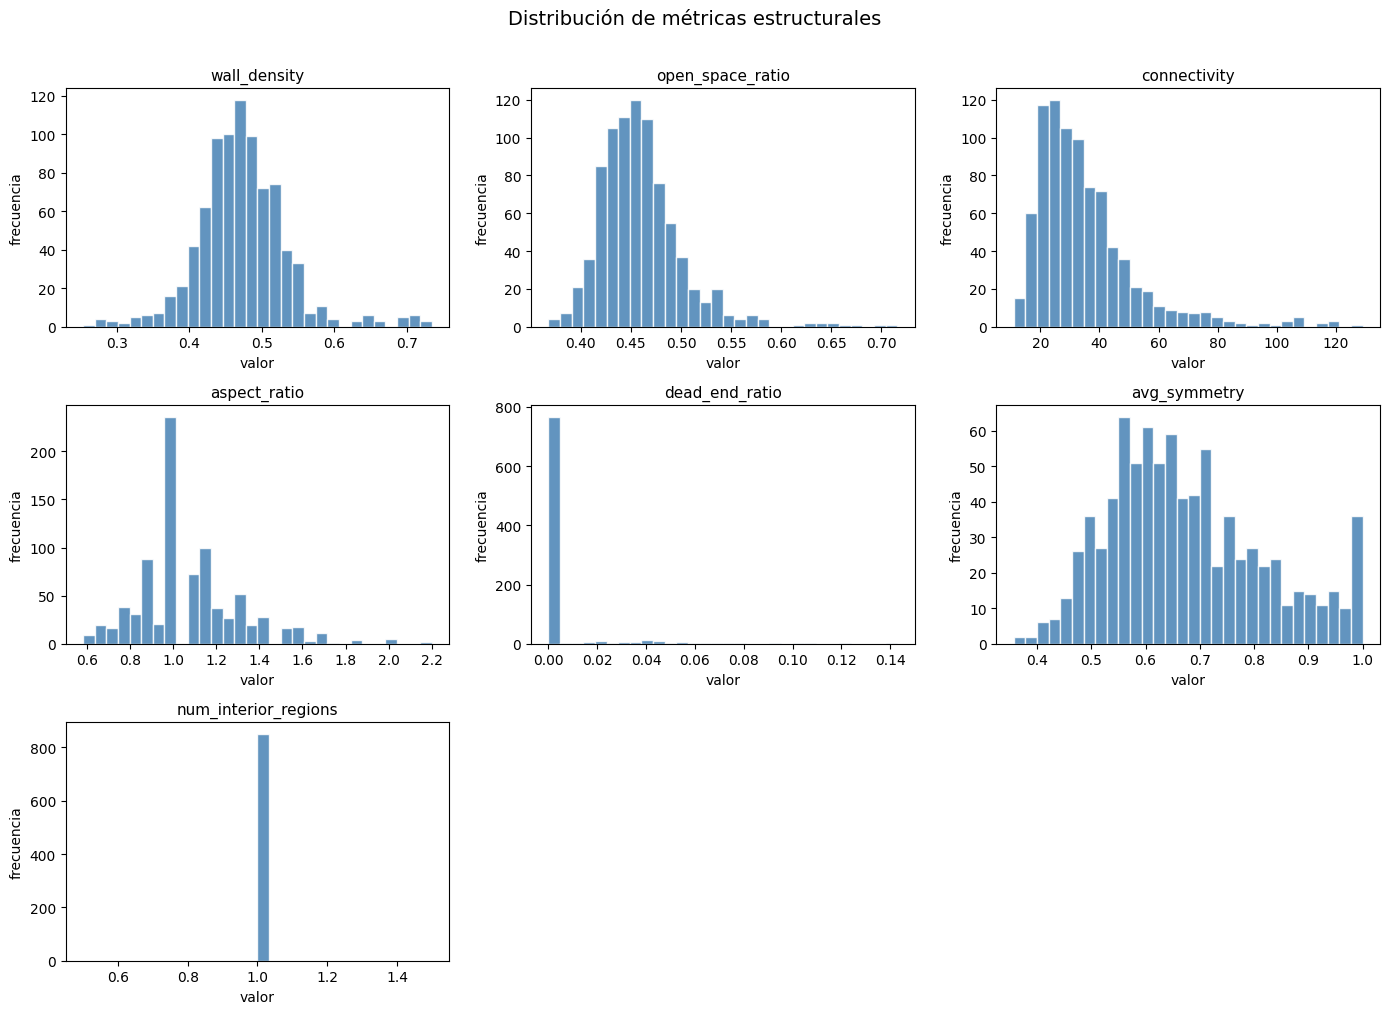

In [6]:
metric_cols = [
    'wall_density', 'open_space_ratio', 'connectivity',
    'aspect_ratio', 'dead_end_ratio', 'avg_symmetry',
    'num_interior_regions'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(metric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('valor')
    axes[i].set_ylabel('frecuencia')

# apagar los 2 subplots sobrantes (tenemos 7 métricas en grilla de 3x3)
for j in range(len(metric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de métricas estructurales', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlación entre métricas

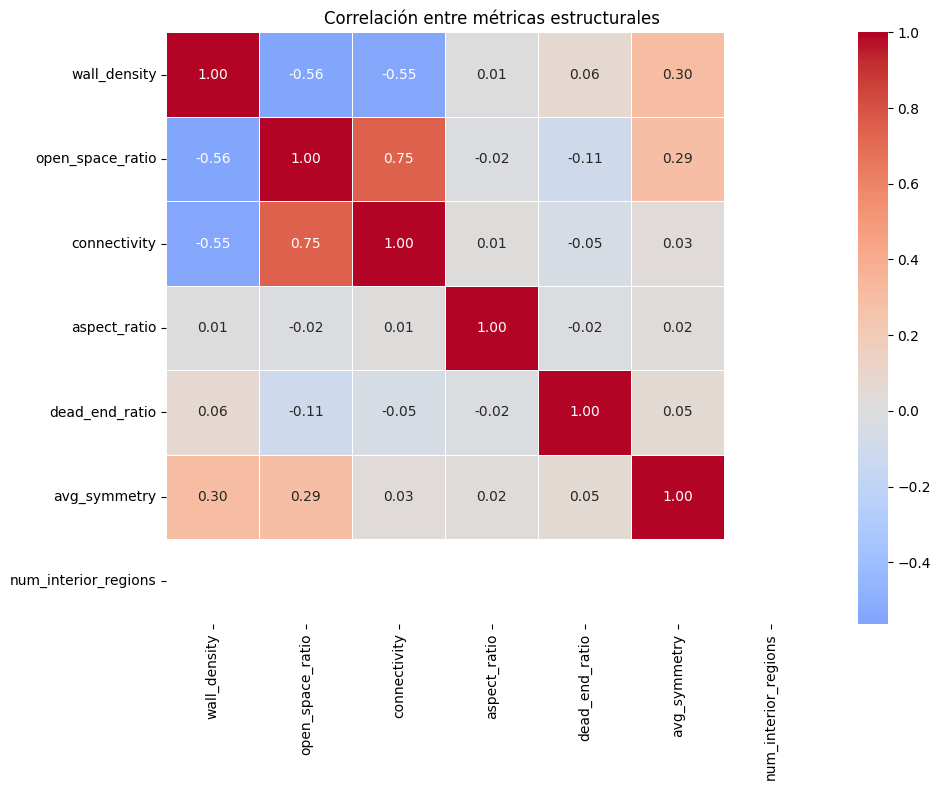

In [7]:
corr = df[metric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlación entre métricas estructurales')
plt.tight_layout()
plt.show()

## 7. Selección de 50 tableros representativos (K-Means)

In [8]:
cluster_features = [
    'wall_density',
    'open_space_ratio',
    'connectivity',
    'dead_end_ratio',
    'aspect_ratio',
    'avg_symmetry',
    'num_interior_regions'
]

X = df[cluster_features].values
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

K = 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_norm)

# Seleccionar el tablero más cercano al centroide de cada cluster
selected_ids = []
for k in range(K):
    cluster_mask = df['cluster'] == k
    cluster_points = X_norm[cluster_mask]
    centroid = kmeans.cluster_centers_[k]
    dists = np.linalg.norm(cluster_points - centroid, axis=1)
    local_idx = np.argmin(dists)
    global_idx = df[cluster_mask].index[local_idx]
    selected_ids.append(df.loc[global_idx, 'shell_id'])

df_selected = df[df['shell_id'].isin(selected_ids)].copy()
print(f'Tableros seleccionados: {len(df_selected)}')
df_selected[['shell_id', 'width', 'height'] + cluster_features].head(10)

Tableros seleccionados: 10


,shell_id,width,height,wall_density,open_space_ratio,connectivity,dead_end_ratio,aspect_ratio,avg_symmetry,num_interior_regions
104,105,12,11,0.439394,0.477477,53,0.00,1.090909,0.583333,1
170,171,8,8,0.484375,0.425926,23,0.00,1.000000,0.656250,1
310,311,9,8,0.430556,0.515625,33,0.00,1.125000,0.902778,1
374,375,9,10,0.444444,0.436620,31,0.00,0.900000,0.533333,1
429,430,10,7,0.500000,0.444444,28,0.00,1.428571,0.742857,1
682,684,7,7,0.632653,0.418605,18,0.00,1.000000,0.775510,1
697,699,8,8,0.546875,0.453125,29,0.00,1.000000,0.906250,1
711,713,11,8,0.443182,0.458333,33,0.00,1.375000,0.534091,1
716,718,8,8,0.515625,0.431034,25,0.08,1.000000,0.656250,1
846,848,14,13,0.423077,0.576923,105,0.00,1.076923,0.807692,1


## 8. Visualización del espacio de clustering

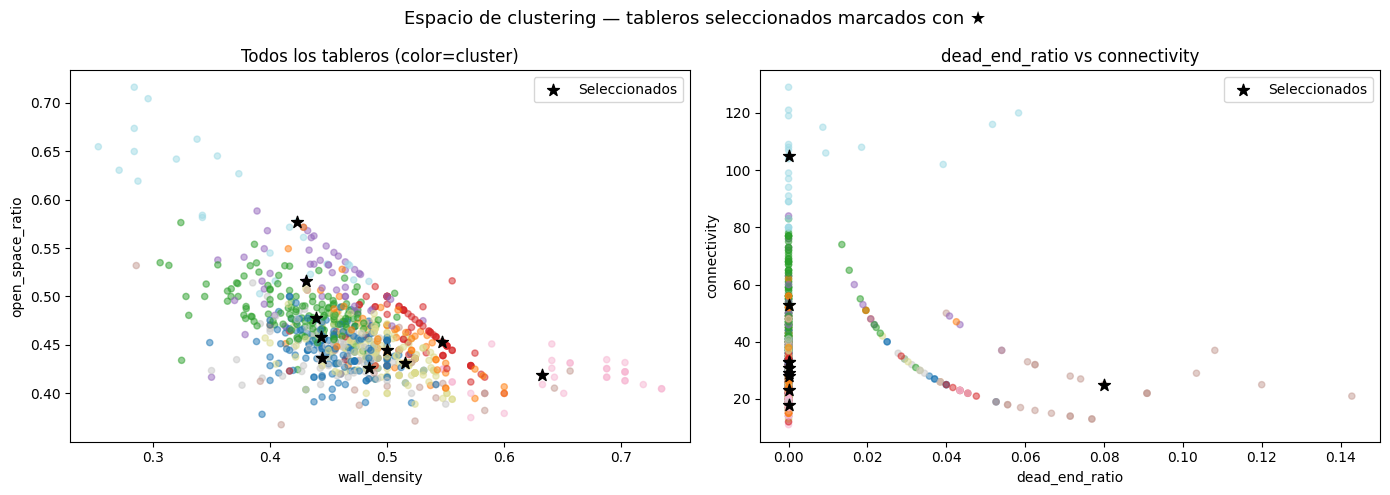

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: wall_density vs open_space_ratio
axes[0].scatter(
    df['wall_density'], df['open_space_ratio'],
    c=df['cluster'], cmap='tab20', alpha=0.5, s=20
)
axes[0].scatter(
    df_selected['wall_density'], df_selected['open_space_ratio'],
    c='black', s=80, marker='*', label='Seleccionados', zorder=5
)
axes[0].set_xlabel('wall_density')
axes[0].set_ylabel('open_space_ratio')
axes[0].set_title('Todos los tableros (color=cluster)')
axes[0].legend()

# Panel derecho: dead_end_ratio vs connectivity
axes[1].scatter(
    df['dead_end_ratio'], df['connectivity'],
    c=df['cluster'], cmap='tab20', alpha=0.5, s=20
)
axes[1].scatter(
    df_selected['dead_end_ratio'], df_selected['connectivity'],
    c='black', s=80, marker='*', label='Seleccionados', zorder=5
)
axes[1].set_xlabel('dead_end_ratio')
axes[1].set_ylabel('connectivity')
axes[1].set_title('dead_end_ratio vs connectivity')
axes[1].legend()

plt.suptitle('Espacio de clustering — tableros seleccionados marcados con ★', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Exportar resultados

In [10]:
# CSV con todas las métricas
df.to_csv('shells_metrics_all.csv', index=False)
print('Exportado: shells_metrics_all.csv')

# CSV solo con los 50 seleccionados
df_selected.to_csv('shells_metrics_selected_10.csv', index=False)
print('Exportado: shells_metrics_selected_10.csv')

# IDs de los seleccionados para usar en Java
ids_str = ','.join(str(i) for i in sorted(selected_ids))
print(f'\nIDs seleccionados ({len(selected_ids)}):')
print(ids_str)

Exportado: shells_metrics_all.csv
Exportado: shells_metrics_selected_10.csv

IDs seleccionados (10):
105,171,311,375,430,684,699,713,718,848


In [13]:
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# =========================================================
# 1. CONFIGURACIÓN
# =========================================================

# Archivos de entrada
METRICS_CSV = "shells_metrics_all.csv"
SHELLS_TXT = "../2_shelders/all_shells_max15.txt"

# Parámetros de selección
TUNING_K = 5   # Tableros para calibrar hiperparámetros con irace
TEST_K = 10    # Tableros para el experimento principal (Sección 3.1)

# Archivos de salida (IDs)
TUNING_CSV_OUT = "tuning_shells_ids.csv"
TEST_CSV_OUT = "test_shells_ids_10.csv"

# Archivos de salida (Tableros físicos)
TUNING_TXT_OUT = "tuning_shells.txt"
TEST_TXT_OUT = "test_shells_10.txt"

# =========================================================
# 2. DOBLE CLUSTERING (TUNING Y TEST)
# =========================================================
print("Iniciando selección por doble K-Means...")

# Cargar el dataset completo
df_all = pd.read_csv(METRICS_CSV)

# Características estructurales
features = [
    'width', 'height', 'wall_density', 'open_space_ratio', 
    'connectivity', 'aspect_ratio', 'dead_end_ratio', 
    'avg_symmetry', 'num_interior_regions'
]

# --- FASE 1: SELECCIÓN PARA TUNING ---
X_all = df_all[features]
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

kmeans_tuning = KMeans(n_clusters=TUNING_K, random_state=42)
kmeans_tuning.fit(X_all_scaled)

closest_tuning, _ = pairwise_distances_argmin_min(kmeans_tuning.cluster_centers_, X_all_scaled)
tuning_ids_array = df_all.iloc[closest_tuning]['shell_id'].values

df_tuning = df_all[df_all['shell_id'].isin(tuning_ids_array)]
df_remaining = df_all[~df_all['shell_id'].isin(tuning_ids_array)].copy()

# --- FASE 2: SELECCIÓN PARA TEST ---
# Se re-escala el espacio solo con los tableros sobrantes
X_remaining = df_remaining[features]
scaler_test = StandardScaler()
X_remaining_scaled = scaler_test.fit_transform(X_remaining)

kmeans_test = KMeans(n_clusters=TEST_K, random_state=42)
kmeans_test.fit(X_remaining_scaled)

closest_test, _ = pairwise_distances_argmin_min(kmeans_test.cluster_centers_, X_remaining_scaled)
test_ids_array = df_remaining.iloc[closest_test]['shell_id'].values

df_test = df_remaining[df_remaining['shell_id'].isin(test_ids_array)]

# Exportar los DataFrames
df_tuning.to_csv(TUNING_CSV_OUT, index=False)
df_test.to_csv(TEST_CSV_OUT, index=False)

tuning_ids = set(df_tuning["shell_id"].astype(int))
test_ids = set(df_test["shell_id"].astype(int))

print(f"Total original de tableros: {len(df_all)}")
print(f"-> Seleccionados para Tuning (irace): {len(tuning_ids)}")
print(f"-> Seleccionados para Test (Experimentos): {len(test_ids)}")

# =========================================================
# 3. EXTRACCIÓN DE TEXTO (PARSEO)
# =========================================================
print("\nParseando archivo de cascarones...")

text = Path(SHELLS_TXT).read_text(encoding="utf-8")
chunks = text.split("=" * 80)

shells = {}

for chunk in chunks:
    chunk = chunk.strip()
    if not chunk:
        continue

    lines = chunk.splitlines()
    shell_id = None

    for line in lines:
        if line.startswith("Shell ID:"):
            shell_id = int(line.replace("Shell ID:", "").strip())
            break

    if shell_id is None:
        continue

    board_lines = []
    capture = False

    for line in lines:
        if line.startswith("Shell ID:") or line.startswith("Width:") or line.startswith("Height:"):
            continue
        if line.strip() == "" and not capture:
            continue

        capture = True
        board_lines.append(line.rstrip("\n\r"))

    board = "\n".join(board_lines).rstrip()
    shells[shell_id] = board

print(f"Cascarones parseados correctamente: {len(shells)}")

# =========================================================
# 4. EXPORTAR CASCARONES SEPARADOS
# =========================================================

def export_shells_to_txt(target_ids, output_filename, parsed_shells):
    exported = 0
    with open(output_filename, "w", encoding="utf-8") as f:
        for shell_id in sorted(target_ids):
            if shell_id not in parsed_shells:
                print(f"ADVERTENCIA: Shell ID {shell_id} no encontrado en el archivo de texto.")
                continue

            f.write(f"Shell ID: {shell_id}\n\n")
            f.write(parsed_shells[shell_id])
            f.write("\n\n" + "=" * 80 + "\n\n")
            exported += 1
            
    print(f"Exportados {exported} tableros a -> {output_filename}")

print("\nGenerando archivos finales...")
export_shells_to_txt(tuning_ids, TUNING_TXT_OUT, shells)
export_shells_to_txt(test_ids, TEST_TXT_OUT, shells)

print("\n¡Proceso finalizado exitosamente!")

Iniciando selección por doble K-Means...
Total original de tableros: 851
-> Seleccionados para Tuning (irace): 5
-> Seleccionados para Test (Experimentos): 10

Parseando archivo de cascarones...
Cascarones parseados correctamente: 851

Generando archivos finales...
Exportados 5 tableros a -> tuning_shells.txt
Exportados 10 tableros a -> test_shells_10.txt

¡Proceso finalizado exitosamente!



Generando visualización del espacio estructural (PCA)...
Gráfico guardado exitosamente como: clustering_test_boards.pdf


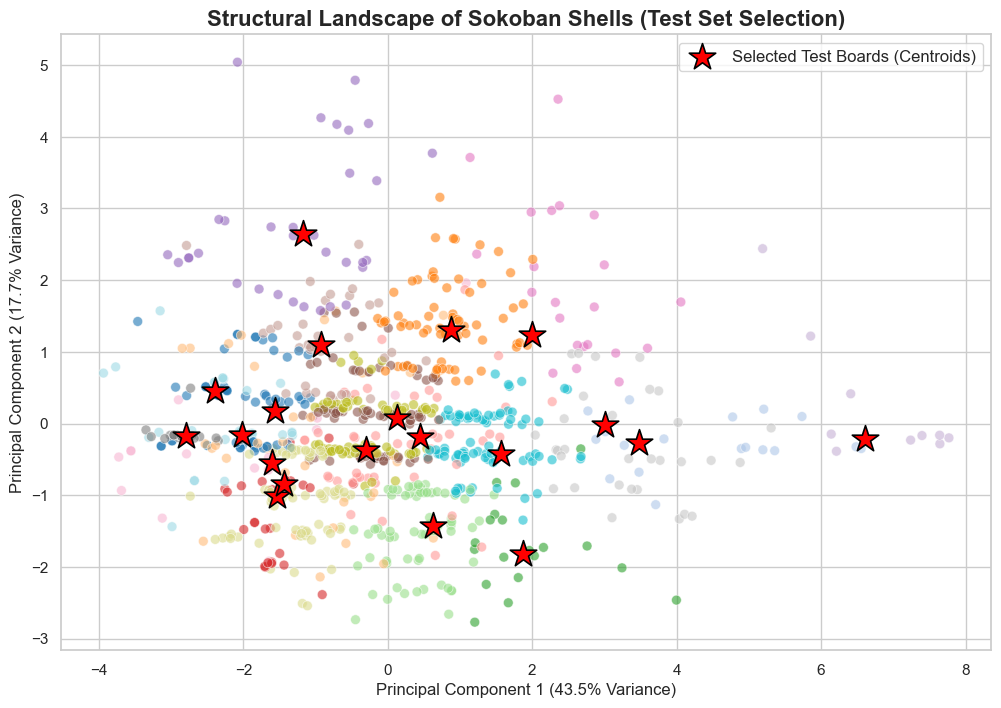

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# =========================================================
# 5. VISUALIZACIÓN DEL CLUSTERING DE TEST (PCA)
# =========================================================
print("\nGenerando visualización del espacio estructural (PCA)...")

# 1. Reducir las 9 dimensiones a 2 componentes principales (PCA)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_remaining_scaled)

# 2. Agregar los resultados del PCA y las etiquetas al DataFrame original sobrante
df_remaining['PCA1'] = X_pca[:, 0]
df_remaining['PCA2'] = X_pca[:, 1]
df_remaining['Cluster'] = kmeans_test.labels_

# 3. Identificar cuáles de estos puntos son nuestros 20 "Centroides" elegidos
df_remaining['Is_Selected'] = df_remaining['shell_id'].isin(test_ids_array)

# 4. Configurar el estilo del gráfico para el paper (estilo académico)
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 5. Dibujar todos los cascarones coloreados por su clúster
sns.scatterplot(
    data=df_remaining, 
    x='PCA1', 
    y='PCA2', 
    hue='Cluster', 
    palette='tab20', # Paleta de 20 colores distinguibles
    alpha=0.6,       # Ligeramente transparentes
    s=50,            # Tamaño de los puntos base
    legend=False     # Ocultamos la leyenda para no saturar el gráfico
)

# 6. Dibujar y resaltar los 20 tableros SELECCIONADOS (estrellas rojas)
selected_points = df_remaining[df_remaining['Is_Selected'] == True]
plt.scatter(
    selected_points['PCA1'], 
    selected_points['PCA2'], 
    c='red', 
    marker='*', 
    s=400,           # Tamaño gigante para las estrellas
    edgecolor='black',
    linewidth=1.2,
    label='Selected Test Boards (Centroids)',
    zorder=5         # Asegura que las estrellas se dibujen por encima del resto
)

# 7. Etiquetas y título con formato académico
variance_explained = pca.explained_variance_ratio_
plt.title('Structural Landscape of Sokoban Shells (Test Set Selection)', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({variance_explained[0]*100:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({variance_explained[1]*100:.1f}% Variance)', fontsize=12)
plt.legend(loc='best', fontsize=12)

# 8. Guardar en alta resolución para el artículo LaTeX
output_image = "clustering_test_boards.pdf" # PDF es ideal para compilar en LaTeX sin perder calidad
plt.savefig(output_image, format='pdf', bbox_inches='tight', dpi=300)
print(f"Gráfico guardado exitosamente como: {output_image}")

# Opcional: mostrarlo en pantalla si estás usando Jupyter Notebook o VS Code interactivo
plt.show()